<a href="https://colab.research.google.com/github/yxngles13/gnn-thermal-hotspot/blob/main/GNN_Based_Thermal_Hotspot_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install torch-geometric

In [48]:
import torch
from sklearn.neighbors import kneighbors_graph
import scipy.sparse
import numpy as np
from torch_geometric.data import Data

def generate_thermal_mesh(n_nodes=300):
    np.random.seed(42)
    pos = np.random.rand(n_nodes, 2)
    conductivity = np.random.rand(n_nodes, 1)

    heat_sources = np.array([[0.2, 0.2], [0.7, 0.7], [0.5, 0.4]])
    power_density = np.zeros((n_nodes, 1))
    for source in heat_sources:
        dist = np.linalg.norm(pos - source, axis=1, keepdims=True)
        power_density += np.exp(-dist**2 / 0.02)
    power_density += np.random.rand(n_nodes, 1) * 0.1

    x = np.hstack([pos, conductivity, power_density])

    A = kneighbors_graph(pos, n_neighbors=6, mode='connectivity', include_self=False)
    A = A + A.T
    cx = A.tocoo()
    edge_index = torch.tensor(np.vstack([cx.row, cx.col]), dtype=torch.long)

    temperature = power_density.flatten() / (conductivity.flatten() + 0.1)
    y = torch.tensor(temperature > np.percentile(temperature, 80), dtype=torch.float)

    return Data(x=torch.tensor(x, dtype=torch.float), edge_index=edge_index, y=y)

# Test it immediately
data = generate_thermal_mesh(n_nodes=300)
print(f"Nodes: {data.x.shape[0]}, Edges: {data.edge_index.shape[1]}")

Nodes: 300, Edges: 2136


In [41]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class ThermalGNN(nn.Module):
  def __init__(self, in_channels, hidden_channels):
    super().__init__()
    self.conv1 = GCNConv(in_channels, hidden_channels)
    self.conv2 = GCNConv(hidden_channels, hidden_channels)
    self.conv3 = GCNConv(hidden_channels, 1)

  def forward(self, x, edge_index):
    x = F.relu(self.conv1(x, edge_index))
    x = F.dropout(x, p=0.3, training=self.training)
    x = F.relu(self.conv2(x, edge_index))
    x = self.conv3(x, edge_index)  # remove torch.sigmoid here
    return x.squeeze()

In [50]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

from torch_geometric.transforms import RandomNodeSplit

# Add train/test masks to data
torch.manual_seed(42)
n = data.x.shape[0]
idx = torch.randperm(n)
train_idx = idx[:240]
test_idx = idx[240:]

train_mask = torch.zeros(n, dtype=torch.bool)
test_mask = torch.zeros(n, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

# Retrain GNN (train on 80%, test on 20%)
model = ThermalGNN(in_channels=4, hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
pos_weight = torch.tensor([n_normal / n_hotspot])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

for epoch in range(500):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Retrain MLP on 80% only
mlp = MLPClassifier(hidden_layer_sizes=(64, 64)).fit(
    data.x[train_mask].numpy(), data.y[train_mask].numpy()
)

# Evaluate both on test set only
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    preds = (torch.sigmoid(out[test_mask]).numpy() > 0.5).astype(int)
    labels = data.y[test_mask].numpy().astype(int)

print("=== GNN Results (test set) ===")
print(classification_report(labels, preds, target_names=["Normal", "Hotspot"]))

print("=== MLP Results (test set) ===")
mlp_preds = mlp.predict(data.x[test_mask].numpy())
print(classification_report(labels, mlp_preds, target_names=["Normal", "Hotspot"]))

Epoch 0, Loss: 1.0547
Epoch 100, Loss: 0.3750
Epoch 200, Loss: 0.3366
Epoch 300, Loss: 0.3137
Epoch 400, Loss: 0.3051
=== GNN Results (test set) ===
              precision    recall  f1-score   support

      Normal       0.88      0.90      0.89        41
     Hotspot       0.78      0.74      0.76        19

    accuracy                           0.85        60
   macro avg       0.83      0.82      0.82        60
weighted avg       0.85      0.85      0.85        60

=== MLP Results (test set) ===
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96        41
     Hotspot       1.00      0.84      0.91        19

    accuracy                           0.95        60
   macro avg       0.97      0.92      0.94        60
weighted avg       0.95      0.95      0.95        60



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


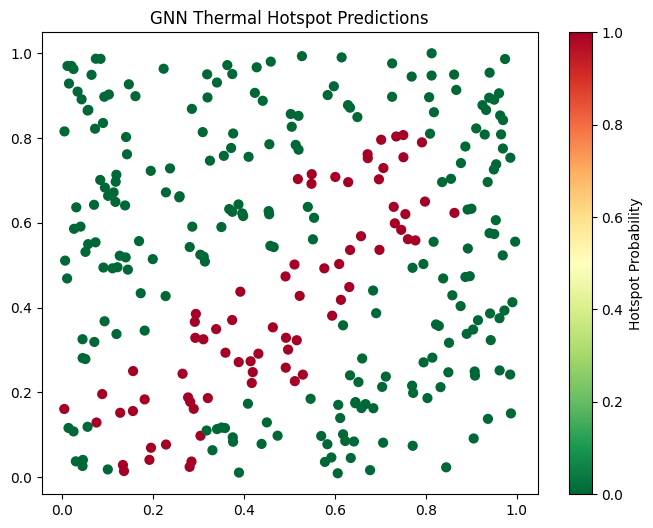

In [51]:
import matplotlib.pyplot as plt

pos = data.x[:, :2].numpy()
preds = (model(data.x, data.edge_index).detach().numpy() > 0.5)

plt.figure(figsize=(8,6))
plt.scatter(pos[:,0], pos[:,1], c=preds, cmap='RdYlGn_r', s=40)
plt.title("GNN Thermal Hotspot Predictions")
plt.colorbar(label="Hotspot Probability")
plt.savefig("thermal_hotspots.png")